# Project: System ID Using Convex Optimization

## Step 1: Importing libraries!

Description:

---

1. CasADi: Library for framing the Non-Linear Program and solving it using an Interior Point Method Optimizer. Importing as * so I don't have to define the library functions. 
2. Matplotlib: Library for plotting the results/data.
3. Pandas: Read csv/excel data sheets. Used for importing the true data derived from the Gazebo Simulator!
4. Numpy: Basic array/matrices library in python. 

In [ ]:
from casadi import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Step 2: Importing the true data from the Gazebo Simulator!

In [3]:
# Read the excel data!
true_data = pd.read_excel('Gazebo_sim_data.xlsx', header = 0)

# Displaying the first 5 rows of the data!
display(true_data.head(5))

,__time,time,theta_dot,theta,input,prismatic_pos,prismatic_vel
0,1.744591e+09,0.00000,0.000000,0.000000,-8.602066,0.000000e+00,0.000000
1,1.744591e+09,0.00087,NaN,NaN,NaN,7.760000e-07,0.000776
2,1.744591e+09,0.00165,NaN,NaN,NaN,2.325000e-06,0.001549
3,1.744591e+09,0.00180,0.010586,0.000026,NaN,NaN,NaN
4,1.744591e+09,0.00274,NaN,NaN,NaN,4.646000e-06,0.002321


Lets plot some of the data to see the controlled inverted pendulum in action!

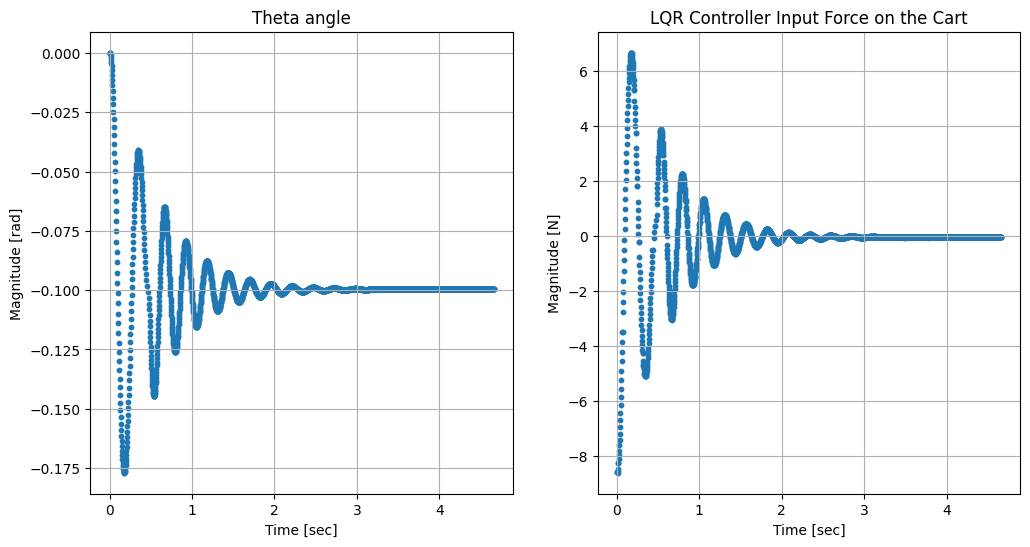

In [4]:
# Plotting
plt.figure(figsize = (12,6))

plt.subplot(1,2,1)
plt.scatter(true_data.iloc[:,1], true_data.iloc[:,3], s = 10)
plt.grid()
plt.title('Theta angle')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad]')

plt.subplot(1,2,2)
plt.scatter(true_data.iloc[:,1], true_data.iloc[:,4], s = 10)
plt.grid()
plt.title('LQR Controller Input Force on the Cart')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [N]')
plt.show()

# Step 3: Interpolate between the data to get the missing values. 

Performing optimization on NaN is not going to lead the solver in the wrong direction. 

In [5]:
# Interpolating along the columns (axis = 0)
true_data = true_data.interpolate(axis = 0)

display(true_data.head(5))

,__time,time,theta_dot,theta,input,prismatic_pos,prismatic_vel
0,1.744591e+09,0.00000,0.000000,0.000000,-8.602066,0.000000e+00,0.000000
1,1.744591e+09,0.00087,0.003529,0.000009,-8.602066,7.760000e-07,0.000776
2,1.744591e+09,0.00165,0.007058,0.000017,-8.602066,2.325000e-06,0.001549
3,1.744591e+09,0.00180,0.010586,0.000026,-8.602066,3.485500e-06,0.001935
4,1.744591e+09,0.00274,0.015275,0.000041,-8.602066,4.646000e-06,0.002321


Fixing the theta angle shift: local body frame => global inertial frame

Text(0, 0.5, 'Magnitude [rad]')

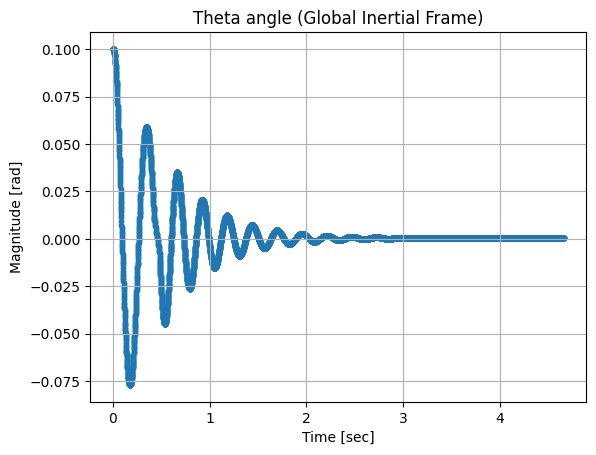

In [6]:
# Adding 0.1 rad (the original theta angle of the pendulum)
true_data.iloc[:,3] = true_data.iloc[:,3] + 0.1

# Plotting the roll angle in the global inertial frame.
plt.figure()
plt.scatter(true_data.iloc[:,1], true_data.iloc[:,3], s = 10)
plt.grid()
plt.title('Theta angle (Global Inertial Frame)')
plt.xlabel('Time [sec]')
plt.ylabel('Magnitude [rad]')

# Step 4: Defining the structure of the NLP (optimization problem)

(a). Defining the variable initializations!

In [7]:
# Number of states = 4
n_states = 4
n_control = 1

# Defining the decision variables: A and B matrices
A = SX.sym('X',n_states,n_states)
B = SX.sym('U',n_states,n_control)

# Defining the PD matrix for the cost function!
Q = DM.eye(n_states)

# LQR Gain Matrix!
K = DM([
    [0, 1.5, 0, 0.4]
])
# Closed loop matrix
A_cl = A - B @ K

(b) Defining the dynamics!

(c) Defining the Cost Function!

In [8]:
# Initialize the cost function!
cost = 0

# Using a for loop to sum up the entire cost function!
for i in range(len(true_data)-1):

    # Get the delta_t
    dt = true_data.iloc[i+1,1] - true_data.iloc[i,1]

    # Get the current state
    curr_state = DM([
        [true_data.iloc[i,5]], [true_data.iloc[i,3]], [true_data.iloc[i,6]], [true_data.iloc[i,2]]
    ])

    # Get the next state
    true_next_state = DM([
        [true_data.iloc[i+1,5]], [true_data.iloc[i+1,3]], [true_data.iloc[i+1,6]], [true_data.iloc[i+1,2]]
    ])

    # Get the current input!
    curr_input = DM([
        [true_data.iloc[i,4]]
    ])
    # Get the estimate of the next state!
    predicted_state = curr_state + dt*(A @ curr_state + B @ curr_input)
    
    # Find the error
    err = true_next_state - predicted_state

    # Update the cost function!
    cost += err.T @ Q @ err

(d) Defining the constraints!

In [ ]:
# Symmetric part of A_cl
M_sym = (A_cl + A_cl.T) / 2

# Sylvester's Criterion: Alternating signs for negative definite
minors = [
    det(M_sym[0:1, 0:1]),       # > 0
    det(M_sym[0:2, 0:2]),       # < 0
    det(M_sym[0:3, 0:3]),       # > 0
    det(M_sym)                  # < 0
]

# Combine all constraints
constraints = vertcat(*minors)

# Bounds on the constraints
lower_bounds_constraints = vertcat(
    DM([-inf, 1e-6, -inf, 1e-6])
)

upper_bounds_constraints = vertcat(
    DM([-1e-6, inf, -1e-6, inf])
)

# Constraints on decision variables
lbx = DM([-100]*20)
ubx = DM([100]*20)

(e) Defining the NLP problem in casADi!

In [31]:
# Define the NLP problem in casADi. 

# Flatten the decision variables of the A and B matrices!
opt_vars = vertcat(A.reshape((-1, 1)), B.reshape((-1, 1)))

# Initialize a dictionary that contains the nlp problem
nlp_prob = {}
nlp_prob['x'] = opt_vars
nlp_prob['f'] = cost
nlp_prob['g'] = constraints

# Define the additional parameters for the solver!
opts = {
    "ipopt.print_level": 0,
    "print_time": False,
    "ipopt.tol": 1e-6,
    "ipopt.dual_inf_tol": 1e-6,
    "ipopt.constr_viol_tol": 1e-6,
    "ipopt.compl_inf_tol": 1e-6,
    "ipopt.acceptable_tol": 1e-5,
    "ipopt.acceptable_obj_change_tol": 1e-6,
}

# Initializing the solver with Interior Point Method!
solver = nlpsol('solver','ipopt',nlp_prob, opts)

(f) Running the optimization routine!

In [55]:
# Provide the initial guesses!
A0 = np.zeros((4,4))
B0 = np.zeros((4,1))
x0 = np.concatenate([A0.flatten(), B0.flatten()])

# Run the Optimization Routine!
sol = solver(x0=x0, lbg=lower_bounds_constraints, ubg=upper_bounds_constraints,lbx = lbx, ubx = ubx)

In [56]:
# Extract solution
x_opt = sol['x']
A_opt = np.array(x_opt[:n_states * n_states]).reshape(n_states, n_states)
B_opt = np.array(x_opt[n_states * n_states:]).reshape(n_states, n_control)

print("Estimated A:\n", A_opt)
print("Estimated B:\n", B_opt)
print("Cost:", float(sol['f']))
print("Solver status:", solver.stats()['return_status'])
print('Iteration count:', solver.stats()['iter_count'])

Estimated A:
 [[ -1.10601502   0.39882288   1.33830796  -3.84791109]
 [ 19.83474062 -99.37916802 -38.58562432  48.25399611]
 [  3.33727398  -1.37166586  -5.36212274   8.72169538]
 [ -0.56443445   0.54461873   0.93197679  -2.85392412]]
Estimated B:
 [[ 0.23186665]
 [-1.14494647]
 [ 0.45111638]
 [ 4.64713317]]
Cost: 0.20114865672564647
Solver status: Solve_Succeeded
Iteration count: 89


# Step 5: Model Validation

Lets take a look at the closed and open loop poles

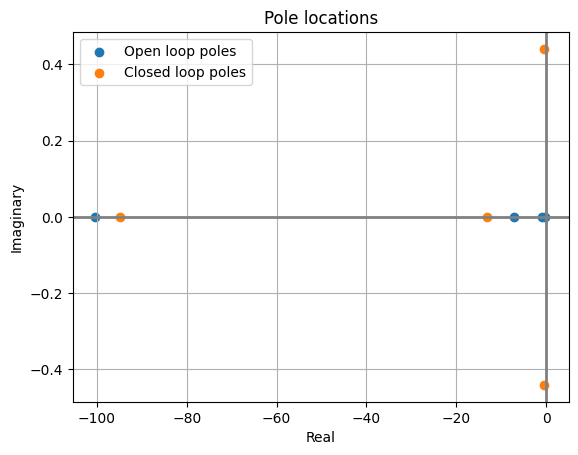

[-94.76744882+0.j         -13.13090403+0.j
  -0.47215531+0.44070691j  -0.47215531-0.44070691j]


In [57]:
open_loop_eig,_ = np.linalg.eig(A_opt)
closed_loop_eig,_ = np.linalg.eig(A_opt - B_opt@K)

plt.figure()
plt.axhline(0, color='gray', linewidth=2)
plt.axvline(0, color='gray', linewidth=2)
plt.scatter(np.real(open_loop_eig), np.imag(open_loop_eig), label='Open loop poles')
plt.scatter(np.real(closed_loop_eig), np.imag(closed_loop_eig), label='Closed loop poles')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Pole locations")
plt.grid(True)
plt.legend()
plt.show()
print(closed_loop_eig)

Test: Trying to update the gains of the controller using the estimated model

29.286711010830725
Solve_Succeeded
23.862872015930016
Solve_Succeeded
17.021035408254004
Solve_Succeeded
74.4106260431672
Solve_Succeeded
92.27093746326727
Solve_Succeeded
2.859709818452505
Solve_Succeeded
5.89249704219168
Solve_Succeeded
43.62304768660968
72.27425668369465
Solve_Succeeded
81.66770234336191


Text(0.5, 1.0, 'Cost Percentage Change for 10 Random Constraints')

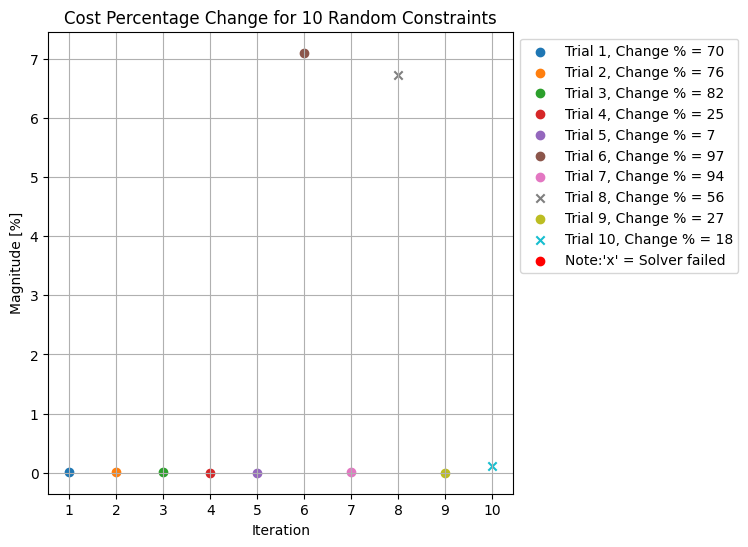

In [64]:
from matplotlib.ticker import MaxNLocator
plt.figure(figsize = (6,6))
for i in range(10):
    change = 100*np.random.rand()
    print(change)
    A0 = np.zeros((4,4))
    B0 = np.zeros((4,1))
    x0 = np.concatenate([A0.flatten(), B0.flatten()])

    lbw = DM(-change * DM.ones(20, 1))
    ubw = DM(change * DM.ones(20, 1))
    # Run the Optimization Routine!
    sol = solver(x0=x0, lbg = lower_bounds_constraints, ubg = upper_bounds_constraints, lbx = lbw, ubx = ubw)

    if solver.stats()['return_status'] != 'Solve_Succeeded':
        plt.scatter(i+1,100*(sol['f'].full()-0.20114865672564647)/0.20114865672564647, label = f'Trial {i+1}, Change % = {int(abs((change-100)))}', marker = 'x')
    else:
        print(solver.stats()['return_status'])
        plt.scatter(i+1,100*(sol['f'].full()-0.20114865672564647)/0.20114865672564647, label = f'Trial {i+1}, Change % = {int(abs((change-100)))}')
plt.scatter([], [], color='red', marker='o', label="Note:'x' = Solver failed")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.xlabel('Iteration')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel('Magnitude [%]')
plt.title('Cost Percentage Change for 10 Random Constraints')